# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


- **Source:** Self-recorded rowing videos (2 female individuals), processed using MediaPipe Pose Landmarker  
- **Samples:** 21,791 frames (256×256 px, skeleton on a black background)  
- **Features:**  
  - 256×256×3 = 196,608 pixel values per frame (for CNNs)  
  - 33 landmarks × 3 coordinates = 99 features (for tabular models)  
- **Labels:** Binary — GOOD vs. BAD

Samples gesamt:  21790
Features:        256×256×3 Pixel pro Frame

Klassenverteilung:
label
GUT    20271
BAD     1519
Name: count, dtype: int64

Videos:
video
cla-GUT-fast-skeleton    6280
cla-GUT-slow-skeleton    5698
mar-GUT-fast-skeleton    4217
mar-GUT-slow-skeleton    4076
cla-BAD-skeleton         1519
Name: count, dtype: int64


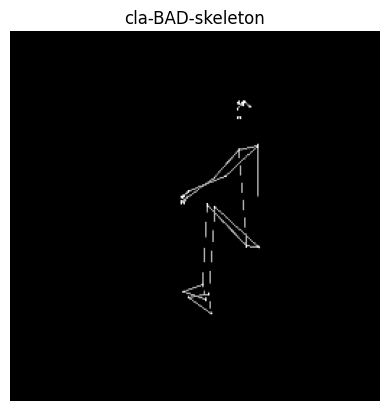

,path,label,video
0,../1_DatasetCharacteristics/Data/skeleton_fram...,BAD,cla-BAD-skeleton
1,../1_DatasetCharacteristics/Data/skeleton_fram...,BAD,cla-BAD-skeleton
2,../1_DatasetCharacteristics/Data/skeleton_fram...,BAD,cla-BAD-skeleton
3,../1_DatasetCharacteristics/Data/skeleton_fram...,BAD,cla-BAD-skeleton
4,../1_DatasetCharacteristics/Data/skeleton_fram...,BAD,cla-BAD-skeleton


In [2]:
FRAMES_BASE = Path("../1_DatasetCharacteristics/Data/skeleton_frames")

label_map = {
    "cla-BAD-skeleton": "BAD",
    "cla-GUT-fast-skeleton": "GUT",
    "cla-GUT-slow-skeleton": "GUT",
    "mar-GUT-fast-skeleton": "GUT",
    "mar-GUT-slow-skeleton": "GUT",
}

samples = []
for folder, label in label_map.items():
    frames = sorted((FRAMES_BASE / folder).glob("*.png"))
    for f in frames:
        samples.append({"path": f, "label": label, "video": folder})

import pandas as pd
df = pd.DataFrame(samples)

print(f"Samples gesamt:  {len(df)}")
print(f"Features:        256×256×3 Pixel pro Frame")
print(f"\nKlassenverteilung:")
print(df["label"].value_counts())
print(f"\nVideos:")
print(df["video"].value_counts())

# Beispiel-Frame anzeigen
example = Image.open(df.iloc[0]["path"])
plt.imshow(example); plt.title(df.iloc[0]["video"]); plt.axis("off"); plt.show()
df.head()


In [13]:
import cv2
from pathlib import Path
import pandas as pd

FRAMES_BASE = Path("Data/skeleton_frames")
VIDEO_DIR   = Path("Data/OG_Videos")

label_map = {
    "cla-BAD-skeleton":       "BAD",
    "cla-GUT-fast-skeleton":  "GUT",
    "cla-GUT-slow-skeleton":  "GUT",
    "mar-GUT-fast-skeleton":  "GUT",
    "mar-GUT-slow-skeleton":  "GUT",
}

rows = []
for folder, label in label_map.items():
    video_stem = folder.replace("-skeleton", "")
    video_path = next(VIDEO_DIR.glob(f"{video_stem}.*"))

    cap = cv2.VideoCapture(str(video_path))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = n_frames / fps
    cap.release()

    m, s = int(duration // 60), duration % 60
    rows.append({
        "Video":   video_stem,
        "Label":   label,
        "Frames":  n_frames,
        "Dauer":   f"{m}m {s:.2f}s",
    })

df_overview = pd.DataFrame(rows)
total = df_overview["Frames"].sum()
df_overview.loc[len(df_overview)] = ["Gesamt", "", total, ""]

df_overview


,Video,Label,Frames,Dauer
0,cla-BAD,BAD,1518,0m 50.62s
1,cla-GUT-fast,GUT,6280,3m 29.42s
2,cla-GUT-slow,GUT,5698,3m 10.00s
3,mar-GUT-fast,GUT,4217,2m 20.63s
4,mar-GUT-slow,GUT,4076,2m 15.93s
5,Gesamt,,21789,


In [14]:
import pandas as pd

# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
df = pd.read_csv('your_dataset.csv')

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
print(df.head())



FileNotFoundError: [Errno 2] No such file or directory: 'your_dataset.csv'

## Handling Missing Values

❌ No missing values

## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


In [ ]:
# Example: Plotting histograms of all numerical features
df.hist(figsize=(12, 12))
plt.show()


## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


### 1. Label Imbalance
The dataset is heavily imbalanced: only 1,520 frames (≈7%) are labeled **BAD**,
while the remaining 20,271 frames (≈93%) are labeled **GOOD**.
This class imbalance may cause a model to be biased towards predicting "good technique".
Thus, I'll generate more data for **bad strokes**.


### 2. Dataset Characteristics and Limitations

At the current stage, the dataset is intentionally homogeneous.  
Only two female participants were recorded in order to develop an initial baseline model capable of learning the fundamental movement patterns and distinguishing between correct and incorrect rowing technique.

This controlled setup provides several advantages during the early development phase:

- Reduced variability in body proportions, movement dynamics, and rowing style
- Easier identification of systematic model errors
- More stable training conditions for initial experiments
- Faster validation of preprocessing and feature extraction pipelines

By limiting the diversity of the dataset in the beginning, the focus can remain on verifying whether the selected architectures and features are able to learn meaningful motion representations at all.

However, this also introduces important limitations:

- The model may overfit to the specific body shapes and movement patterns of the recorded individuals
- Generalization to other athletes, genders, body types, or rowing styles is currently limited
- The dataset does not yet capture realistic variability found in real-world rowing scenarios

Future work should therefore include:

- Recording additional participants with diverse physical characteristics
- Increasing variation in rowing intensity, posture, and camera perspectives

The current dataset should therefore be considered a proof-of-concept foundation for developing and validating the overall machine learning pipeline before scaling toward a more generalized and representative dataset.

In [ ]:
# Example: Checking for class imbalance in a classification problem
# sns.countplot(x='target_variable', data=df)

# Your code to investigate possible biases goes here


## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


In [ ]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()
